# Quantum Machine Learning with a TwoLocal Variational Classifier -- 4-Label Checkerboard (PennyLane)

This notebook is a **PennyLane re-implementation** of
[`../Parallel_QML_Checkerboard4L.ipynb`](../Parallel_QML_Checkerboard4L.ipynb),
which trains and evaluates a variational quantum classifier with **Qiskit** on
a 2-D, **4-class** checkerboard dataset (`checkerboard-4L-4Q`), available in 10
independent instances.

This is the multiclass counterpart of
[`../../pennylane_implementation/Parallel_QML_PennyLane.ipynb`](../../pennylane_implementation/Parallel_QML_PennyLane.ipynb)
-- same overall workflow, but a different circuit:

- a **ZZFeatureMap** encoder (`reps=2`, full entanglement) for the two input
  features, and
- a **TwoLocal** (`ry`, `rz`, `cz`, *full* entanglement, `reps=1`) variational
  ansatz acting on **4 qubits** (2 encoding qubits + 2 extra "workspace"
  qubits, giving a **2-bit** label readout for the 4 classes), re-uploaded
  **2 times**, trained with **SPSA**.

Two circuit constructions are provided, exactly mirroring the Qiskit notebook:
- **Method 1** -- one circuit per data point.
- **Method 2** -- all data points encoded in superposition through an index
  register (amplitude/QRAM-style batch encoding).

The gate-level circuits were reverse-engineered from Qiskit's `ZZFeatureMap` /
`TwoLocal` decompositions and verified to reproduce **bit-identical
predictions** from the Qiskit-trained parameters shipped in
[`../results`](../results) -- see
[`verify_against_qiskit.py`](verify_against_qiskit.py).

All PennyLane-specific code lives in this folder
([`multiclass/pennylane_implementation/`](.)): [`qml_core.py`](qml_core.py)
(circuits/classifiers) and [`train.py`](train.py) (a small framework-agnostic
SPSA optimizer) -- standalone copies of the binary-classification versions,
generalized to a 4-qubit ansatz and 4-way classification.

## How to use this notebook
1. Edit the **Configuration** cell below.
2. *Run All*. Everything else happens automatically and is displayed inline.

> **Tip:** Set `MODE = "load"` to load the parameters trained by the original
> Qiskit notebook and re-evaluate them with the PennyLane circuits (a live
> cross-framework consistency check), or `MODE = "train"` to train from scratch
> using PennyLane + SPSA.

## 1. Configuration  *(the only cell you normally edit)*

In [32]:
# ============================ USER SETTINGS ============================
# Pick the instance:  an integer from 1 to 10
DATASET_NUM = 6

# What to do:
#   "load"  -> load the Qiskit-trained parameters shipped in ../results and
#              re-evaluate them with the PennyLane circuits (fast; also acts as
#              a cross-framework correctness check)
#   "train" -> train the PennyLane circuits from scratch with SPSA (slower)
MODE = "train"

# Which circuit construction(s) to run / display:
#   [1]    -> only Method 1 (one circuit per sample)
#   [2]    -> only Method 2 (all samples in superposition)
#   [1, 2] -> both, shown side by side
METHODS = [1, 2]

# --- settings used only when MODE == "train" ---
MAXITER = 1800      # SPSA iterations (the shipped results used ~400; Method 2 is
                    # the slow one: ~3s/evaluation, 3 evaluations/iteration ->
                    # roughly 3 * 3 * MAXITER seconds, e.g. ~15 min for 100 iters)
SEED    = 42        # random seed for the initial parameters (reproducibility)

# --- visualization ---
PLOT_DECISION_BOUNDARY = False   # draw the learned decision boundary (a bit slower)
GRID_RES = 60                    # resolution of the decision-boundary grid
# ======================================================================

assert 1 <= DATASET_NUM <= 10
assert MODE in {"load", "train"}
assert all(m in (1, 2) for m in METHODS) and len(METHODS) >= 1
print(f"Dataset : checkerboard-4L-4Q / dataset{DATASET_NUM}")
print(f"Mode    : {MODE}   |   Method(s): {METHODS}")

Dataset : checkerboard-4L-4Q / dataset6
Mode    : train   |   Method(s): [1, 2]


## 2. Imports

In [33]:
import os
import json
import glob
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pennylane as qml

sys.path.insert(0, os.path.abspath("."))
from qml_core import (
    Method1Classifier, Method2Classifier, OpaqueBlock,
    zz_feature_map_qfunc, two_local_block, two_local_num_params,
)
from train import OptimizerLog, spsa_minimize

warnings.filterwarnings("ignore")
np.random.seed(SEED)

# 4 discrete colors used throughout for the 4 classes (0, 1, 2, 3)
CLASS_COLORS = ListedColormap(["#3b4cc0", "#7ea0f9", "#f7a889", "#b40426"])
CLASS_NORM   = BoundaryNorm(np.arange(-0.5, 4.5, 1), CLASS_COLORS.N)

print("PennyLane version:", qml.__version__)

PennyLane version: 0.40.0


## 3. Load the selected dataset

Train data : (128, 2),  labels: (128,)
Test  data : (64, 2),  labels: (64,)
Classes    : [0, 1, 2, 3]


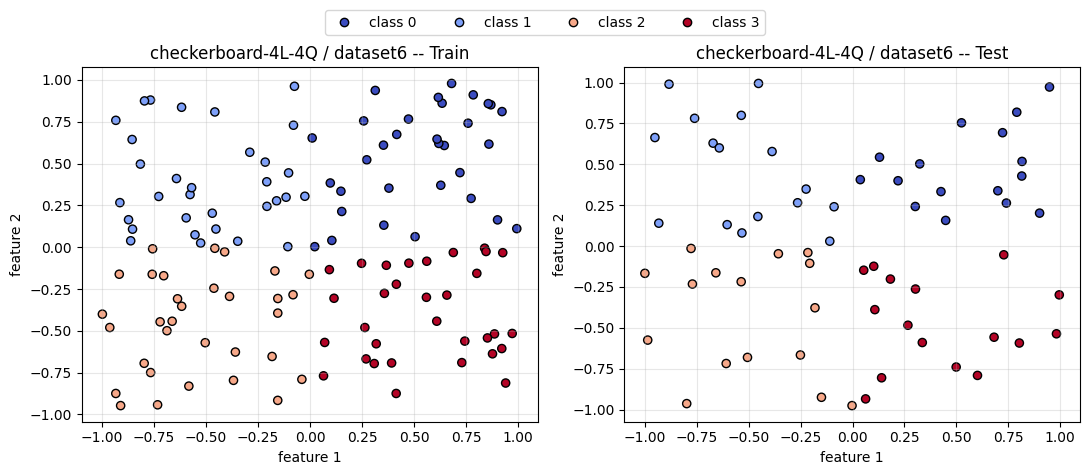

In [34]:
# os.path.abspath collapses the ".." segment against cwd -- this project's
# path is deep enough that the un-resolved relative path can exceed Windows'
# 260-char MAX_PATH limit for some file APIs (os.path.normpath alone is not
# enough: it can't collapse ".." without an absolute base to collapse it into).
DATA_DIR    = os.path.abspath(os.path.join("..", "datasets", f"dataset{DATASET_NUM}"))
RESULTS_DIR = os.path.abspath(os.path.join("..", "results",  f"checkerboard-4L-4Q-dataset{DATASET_NUM}"))

train_data   = pd.read_csv(os.path.join(DATA_DIR, "train_data")).to_numpy()
train_labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels")).to_numpy().flatten()
test_data    = pd.read_csv(os.path.join(DATA_DIR, "test_data")).to_numpy()
test_labels  = pd.read_csv(os.path.join(DATA_DIR, "test_labels")).to_numpy().flatten()

print(f"Train data : {train_data.shape},  labels: {train_labels.shape}")
print(f"Test  data : {test_data.shape},  labels: {test_labels.shape}")
print(f"Classes    : {sorted(np.unique(train_labels).tolist())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, X, y, name in [(axes[0], train_data, train_labels, "Train"),
                       (axes[1], test_data,  test_labels,  "Test")]:
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CLASS_COLORS, norm=CLASS_NORM,
               edgecolors="k", s=35)
    ax.set_title(f"checkerboard-4L-4Q / dataset{DATASET_NUM} -- {name}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.grid(alpha=0.3)
handles = [plt.Line2D([0], [0], marker="o", color="w", markeredgecolor="k",
                      markerfacecolor=CLASS_COLORS(i), label=f"class {i}")
          for i in range(4)]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

## 4. Quantum-circuit hyperparameters

In [35]:
num_reupload = 2
num_features = train_data.shape[1]

clf1 = Method1Classifier(n_features=num_features, num_reupload=num_reupload)
clf2 = Method2Classifier(n_features=num_features, num_reupload=num_reupload,
                          num_data=len(train_data)) if 2 in METHODS else None

num_parameters = clf1.num_parameters
num_ansatz_q = clf1.n_ansatz
num_register = clf2.n_index if clf2 is not None else int(np.log2(len(train_data)))

print(f"Re-uploads        : {num_reupload}")
print(f"Encoding qubits   : {num_features}")
print(f"Ansatz qubits     : {num_ansatz_q}  (encoding + workspace register)")
print(f"Index register    : {num_register} qubits  (Method 2)")
print(f"Trainable params  : {num_parameters}")
print(f"Classes           : {clf1.n_classes}  (2-bit readout: '00', '01', '10', '11')")
print(f"Method 1 device   : {clf1.dev.short_name if hasattr(clf1.dev, 'short_name') else clf1.dev.name}")
if clf2 is not None:
    print(f"Method 2 device   : {clf2.dev.short_name if hasattr(clf2.dev, 'short_name') else clf2.dev.name}")

Re-uploads        : 2
Encoding qubits   : 2
Ansatz qubits     : 4  (encoding + workspace register)
Index register    : 7 qubits  (Method 2)
Trainable params  : 32
Classes           : 4  (2-bit readout: '00', '01', '10', '11')
Method 1 device   : default.qubit
Method 2 device   : lightning.qubit


## 5. Circuit definitions

**Method 1** builds one circuit per data point: the ZZFeatureMap re-encodes
the data onto the first 2 ("encoding") qubits at every re-upload, while the
TwoLocal ansatz acts on all 4 qubits (encoding + 2 extra "workspace" qubits).
Classification reads out the *encoding* qubits' joint 2-bit state -- the
workspace qubits are discarded; they only exist to give the ansatz more
expressive power.

**Method 2** encodes the whole dataset in superposition using an index
register, exactly like the binary classifier, but the labels are now 4-way:
the dataset is pre-sorted into 4 contiguous, equal-size blocks (class 0, 1, 2,
3 in order), so the *top 2 bits* of the index register equal the true class.
A label qubit is flipped whenever (true class, from the index register) ==
(predicted class, from the 2 encoding qubits), via 4 multi-controlled-X gates
(one per class) -- this exactly mirrors `qc2()` in the original notebook.

The two encoder/variational sub-circuits below are drawn for reference.

ZZFeatureMap encoder (reps=2, full entanglement, 2 qubits):


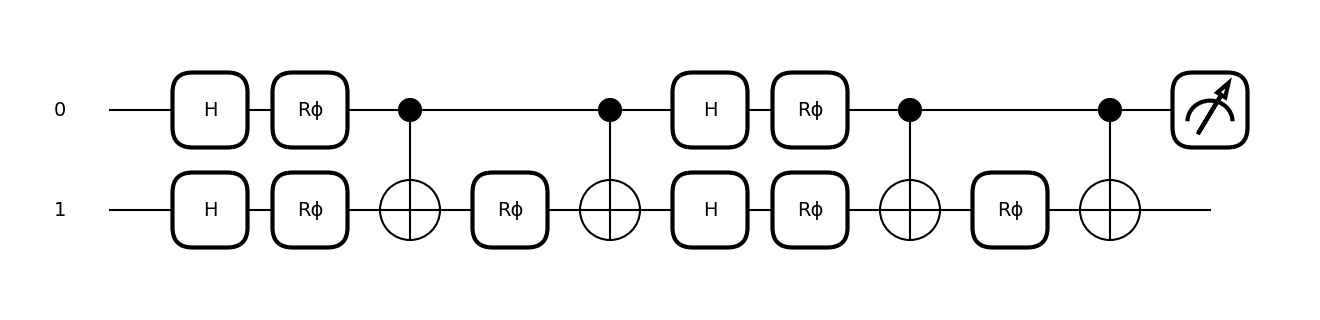

TwoLocal ansatz (ry, rz, cz, full entanglement, reps=1, 4 qubits):


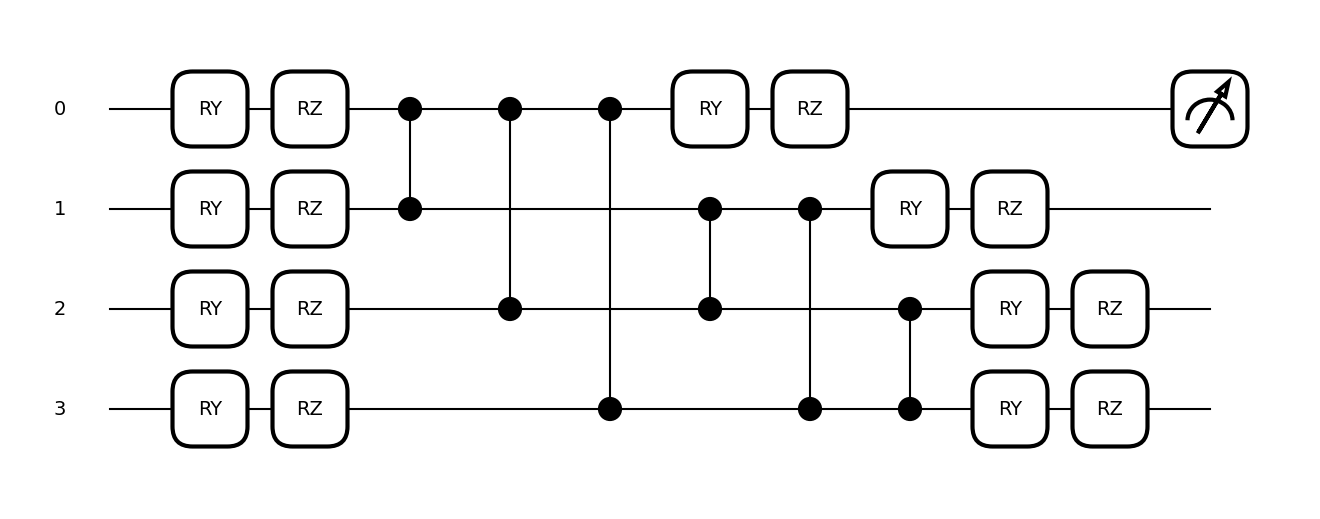

In [36]:
# Reference drawings of the building blocks (single circuit, no re-upload)
example_data = train_data[0]
example_params = np.zeros(two_local_num_params(num_ansatz_q, reps=1))

dev_ref_enc = qml.device("default.qubit", wires=num_features)
dev_ref_var = qml.device("default.qubit", wires=num_ansatz_q)

@qml.qnode(dev_ref_enc)
def _draw_encoder():
    zz_feature_map_qfunc(example_data, list(range(num_features)), reps=2)
    return qml.probs(wires=0)

@qml.qnode(dev_ref_var)
def _draw_ansatz():
    two_local_block(example_params, list(range(num_ansatz_q)), reps=1)
    return qml.probs(wires=0)

print("ZZFeatureMap encoder (reps=2, full entanglement, 2 qubits):")
qml.draw_mpl(_draw_encoder)()
plt.show()

print(f"TwoLocal ansatz (ry, rz, cz, full entanglement, reps=1, {num_ansatz_q} qubits):")
qml.draw_mpl(_draw_ansatz)()
plt.show()

=== Method 1 circuit ===


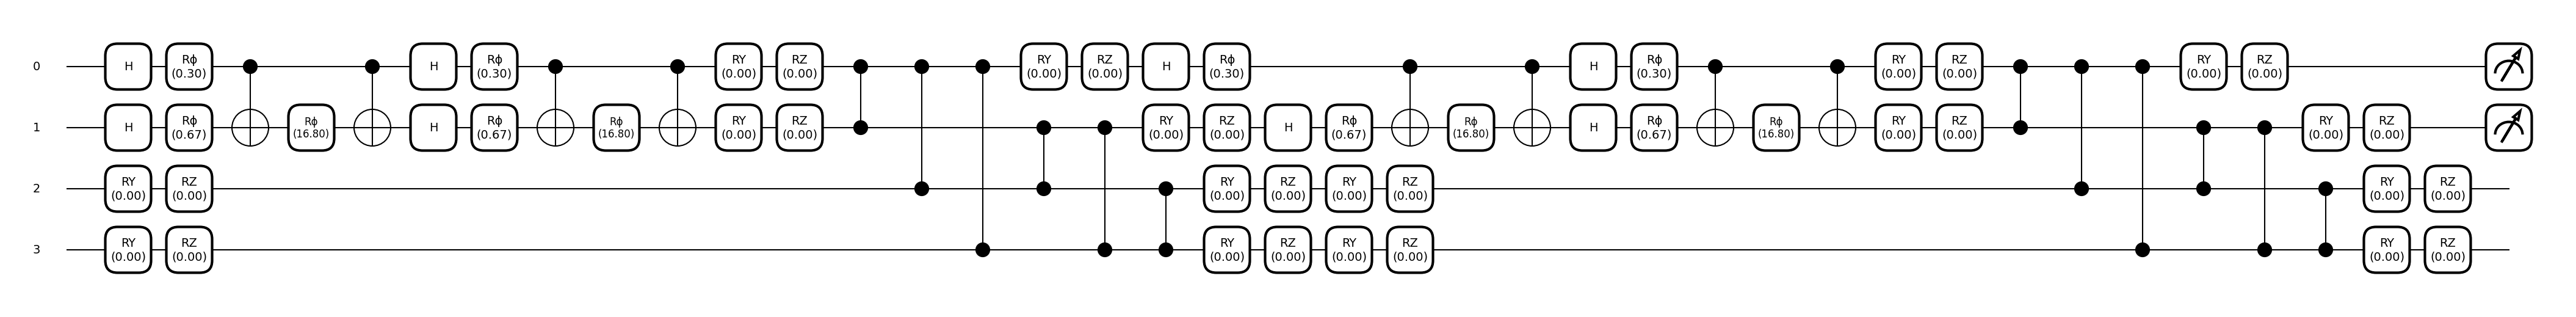

In [37]:
# Method 1: the actual per-sample circuit (compact enough to draw in full)
if 1 in METHODS:
    print("=== Method 1 circuit ===")
    qml.draw_mpl(clf1._qnode, decimals=2)(train_data[0], np.zeros(num_parameters))
    plt.show()

=== Method 2 circuit (schematic; 'Enc' hides one controlled block per training point, 128 of them) ===


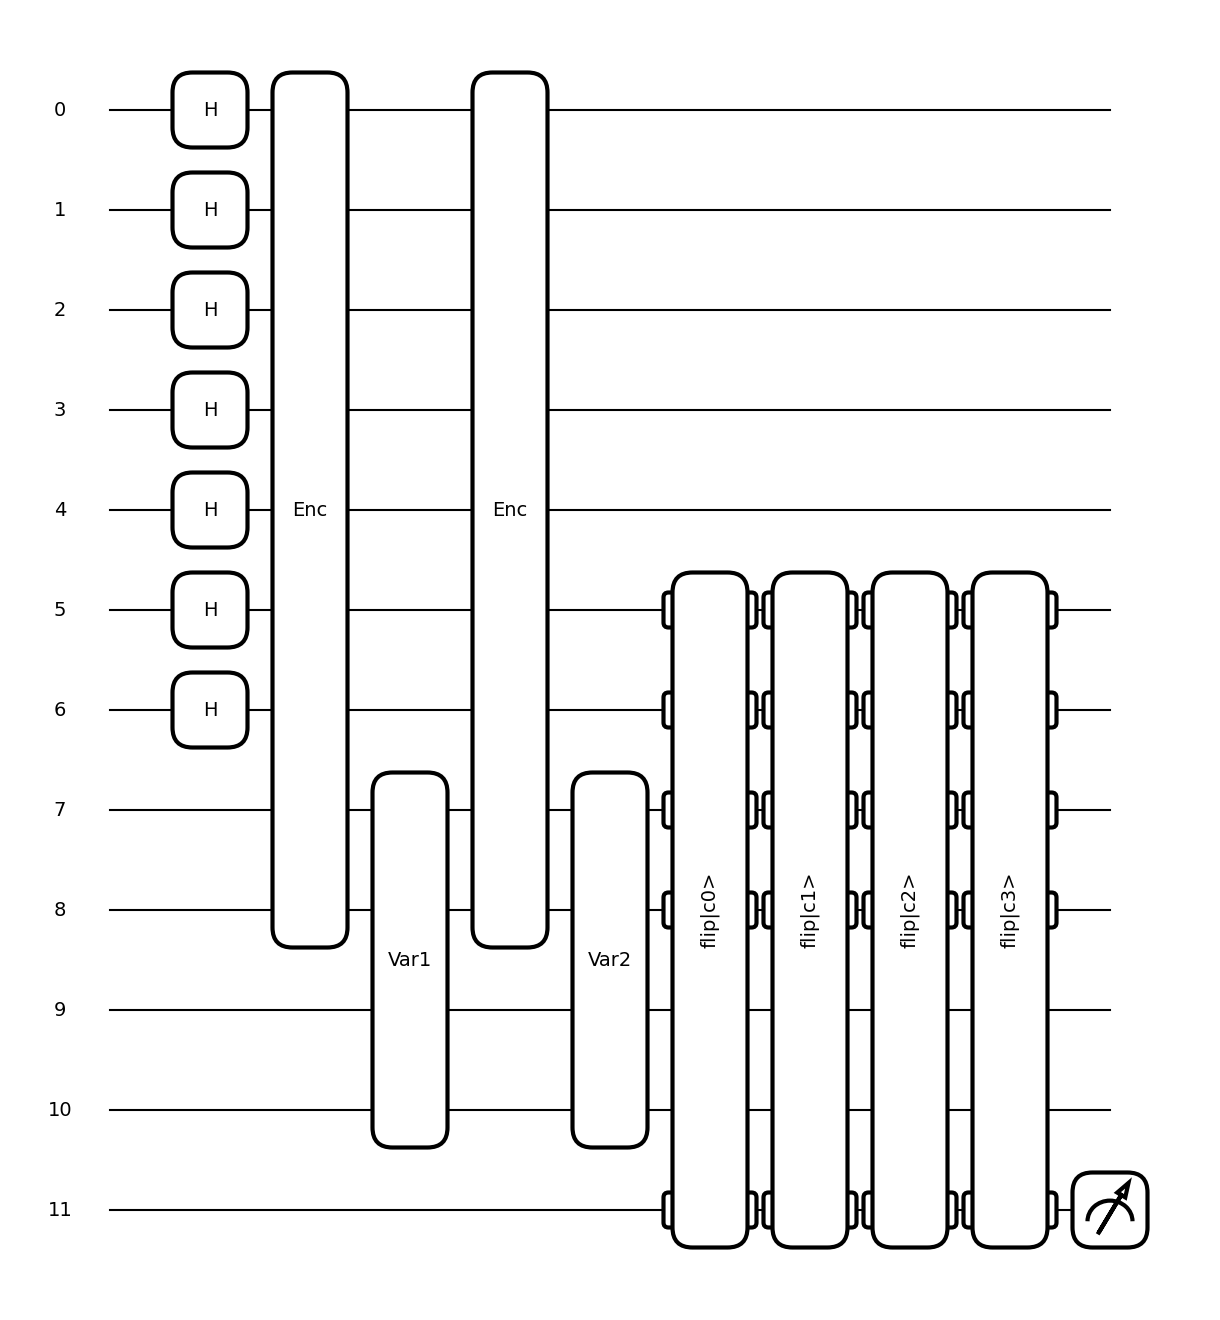

In [38]:
# Method 2: schematic circuit. The real circuit applies one controlled
# encoder block per training point (len(train_data) of them per re-upload --
# far too many to render legibly), so -- exactly like the original notebook's
# qc2(), which bundles the whole encoder into a single named Qiskit Gate via
# .to_gate() -- we draw it with each block collapsed into one labeled box.
if 2 in METHODS:
    print("=== Method 2 circuit (schematic; 'Enc' hides one controlled block per "
          f"training point, {len(train_data)} of them) ===")

    dev_schematic = qml.device("default.qubit", wires=clf2.total_wires)

    @qml.qnode(dev_schematic)
    def _draw_method2():
        for w in clf2.index_wires:
            qml.Hadamard(wires=w)
        for layer in range(num_reupload):
            OpaqueBlock(wires=clf2.index_wires + clf2.encoding_wires, label_text="Enc")
            OpaqueBlock(wires=clf2.ansatz_wires, label_text=f"Var{layer + 1}")
        for c in range(clf2.n_classes):
            OpaqueBlock(
                wires=[clf2.index_wires[-1], clf2.index_wires[-2],
                       clf2.encoding_wires[0], clf2.encoding_wires[1], clf2.label_wire],
                label_text=f"flip|c{c}>",
            )
        return qml.probs(wires=clf2.label_wire)

    qml.draw_mpl(_draw_method2, fold=-1)()
    plt.show()

## 6. Training / evaluation functions

Accuracy is always measured with the Method-1 per-sample circuit (`clf1`), so
trained parameters from either method are evaluated consistently -- exactly as
in the original notebook.

In [39]:
def performance_evaluation(data, labels, variational):
    '''Return (accuracy, predictions) using the Method-1 read-out.'''
    return clf1.performance_evaluation(data, labels, variational)


def cost_function_1(variational):
    return clf1.cost(train_data, train_labels, variational)


def cost_function_2(variational):
    return clf2.cost(train_data, variational)


def make_evaluate_fn():
    def evaluate_fn(variational):
        tr, _ = performance_evaluation(train_data, train_labels, variational)
        te, _ = performance_evaluation(test_data, test_labels, variational)
        return tr, te
    return evaluate_fn

## 7. Run training **or** load the saved results

Loops over every method in `METHODS` and fills a `results` dictionary --
`results[m]["history"]` and `results[m]["final_params"]` -- regardless of
whether you trained live (`MODE="train"`) or loaded the Qiskit-trained
parameters (`MODE="load"`). The shipped result files are timestamped dumps
(`results_spsa_method{1,2}_<timestamp>.json`), so "load" mode globs for the
single matching file per dataset/method, exactly like the original notebook.

In [ ]:
results = {}

for METHOD in METHODS:
    print(f"\n########## Method {METHOD} ##########")
    if MODE == "train":
        print(f"Training Method {METHOD} with SPSA ({MAXITER} iterations)...\n")
        np.random.seed(SEED)
        initial_point = np.random.uniform(-np.pi, np.pi, size=num_parameters)

        objective = cost_function_1 if METHOD == 1 else cost_function_2
        log = OptimizerLog(make_evaluate_fn())

        t0 = time.time()
        final_params, final_cost = spsa_minimize(
            objective, initial_point, maxiter=MAXITER, log=log, seed=SEED)
        elapsed = time.time() - t0

        history = {
            "costs": log.costs,
            "train_accuracies": log.train_accuracies,
            "test_accuracies": log.test_accuracies,
            "stepsizes": log.stepsizes,
            "final_cost": float(final_cost),
        }
        print(f"\nDone in {elapsed:.1f}s. Final cost = {final_cost:.6f}")

    else:  # MODE == "load"
        pattern = os.path.join(RESULTS_DIR, f"results_spsa_method{METHOD}_*.json")
        matches = sorted(glob.glob(pattern))
        assert matches, f"No result file found matching: {pattern}"
        json_path = matches[-1]
        print(f"Loading Qiskit-trained results from: {json_path}")
        with open(json_path, encoding="utf-8") as f:
            saved = json.load(f)
        th = saved["training_history"]
        fr = saved["final_results"]
        history = {
            "costs": th["costs"],
            "train_accuracies": th["train_accuracies"],
            "test_accuracies": th["test_accuracies"],
            "stepsizes": th["stepsizes"],
            "final_cost": fr["final_cost"],
        }
        final_params = np.array(fr["final_parameters"])
        print(f"Loaded {len(history['costs'])} iterations "
              f"(optimizer: {saved['experiment_info']['optimizer']})")

        # Cross-framework check: re-evaluate the Qiskit-trained parameters with
        # the PennyLane circuits and confirm the predictions agree exactly.
        pl_test_acc, pl_test_pred = performance_evaluation(test_data, test_labels, final_params)
        qiskit_test_pred = fr["test_predictions"]
        agreement = np.mean([int(a == b) for a, b in zip(pl_test_pred, qiskit_test_pred)])
        print(f"PennyLane re-evaluation: test_acc={pl_test_acc:.4f} "
              f"(qiskit reported {fr['final_test_accuracy']:.4f}), "
              f"prediction agreement with Qiskit = {agreement:.4f}")

    results[METHOD] = {"history": history, "final_params": final_params}


########## Method 1 ##########
Training Method 1 with SPSA (1800 iterations)...

 Iter   1: loss=1.4380  train_acc=0.2344  test_acc=0.2188  step=0.7409
 Iter   2: loss=1.4312  train_acc=0.2578  test_acc=0.2500  step=0.7385
 Iter   3: loss=1.3773  train_acc=0.3125  test_acc=0.3125  step=0.7360
 Iter   4: loss=1.3338  train_acc=0.3828  test_acc=0.3750  step=0.7336
 Iter   5: loss=1.3206  train_acc=0.4375  test_acc=0.4688  step=0.7312
 Iter   6: loss=1.3121  train_acc=0.4141  test_acc=0.4531  step=0.7289
 Iter   7: loss=1.3095  train_acc=0.4297  test_acc=0.4375  step=0.7265
 Iter   8: loss=1.3060  train_acc=0.4453  test_acc=0.4219  step=0.7242
 Iter   9: loss=1.3062  train_acc=0.4375  test_acc=0.4219  step=0.7219
 Iter  10: loss=1.2995  train_acc=0.4375  test_acc=0.4219  step=0.7196
 Iter  11: loss=1.2902  train_acc=0.4766  test_acc=0.5000  step=0.7173
 Iter  12: loss=1.2874  train_acc=0.4688  test_acc=0.4688  step=0.7151
 Iter  13: loss=1.3004  train_acc=0.4219  test_acc=0.3906  step=0.

## 8. Training curves

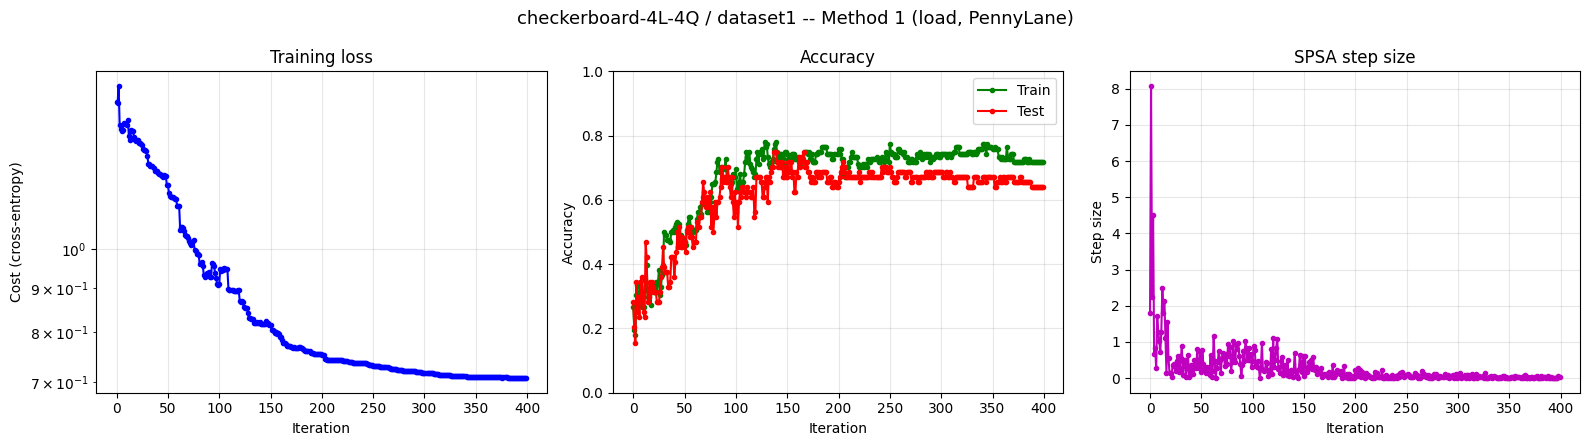

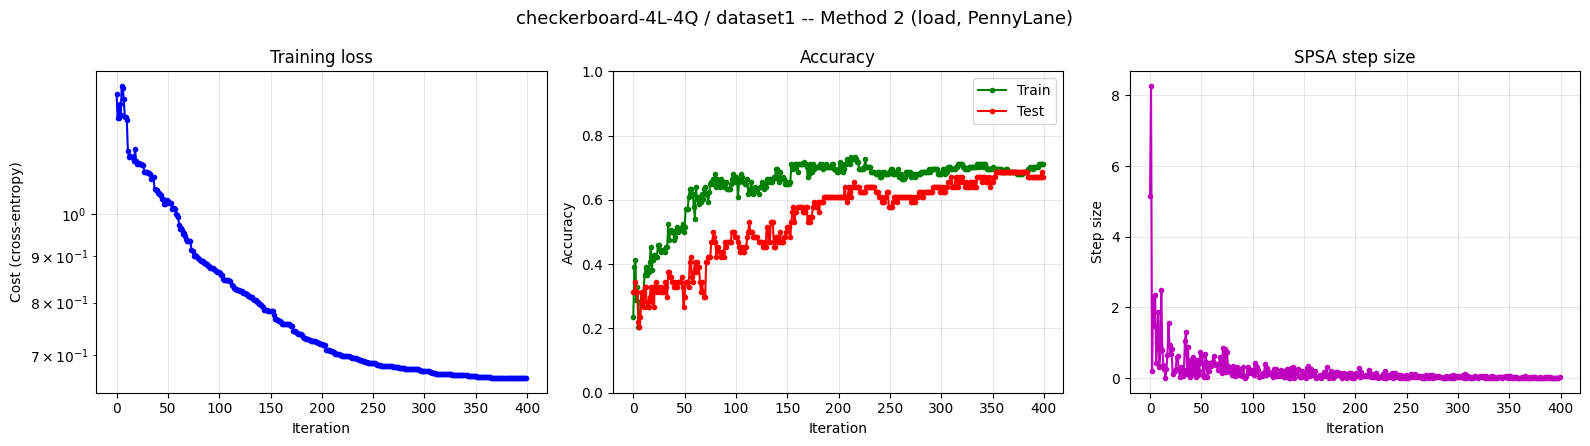

In [10]:
for METHOD in METHODS:
    history = results[METHOD]["history"]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(history["costs"], 'b-o', ms=3)
    ax[0].set_yscale('log'); ax[0].set_title("Training loss")
    ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Cost (cross-entropy)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(history["train_accuracies"], 'g-o', ms=3, label="Train")
    ax[1].plot(history["test_accuracies"],  'r-o', ms=3, label="Test")
    ax[1].set_ylim(0, 1); ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Accuracy")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].plot(history["stepsizes"], 'm-o', ms=3)
    ax[2].set_title("SPSA step size")
    ax[2].set_xlabel("Iteration"); ax[2].set_ylabel("Step size")
    ax[2].grid(alpha=0.3)

    fig.suptitle(f"checkerboard-4L-4Q / dataset{DATASET_NUM} -- Method {METHOD} ({MODE}, PennyLane)",
                 fontsize=13)
    plt.tight_layout(); plt.show()

## 9. Predictions and decision boundary

Predictions are computed with the trained parameters. The decision boundary
(4 discrete classes) is evaluated on a grid using the Method-1 read-out (set
`PLOT_DECISION_BOUNDARY=False` in the config to skip the slower grid evaluation).

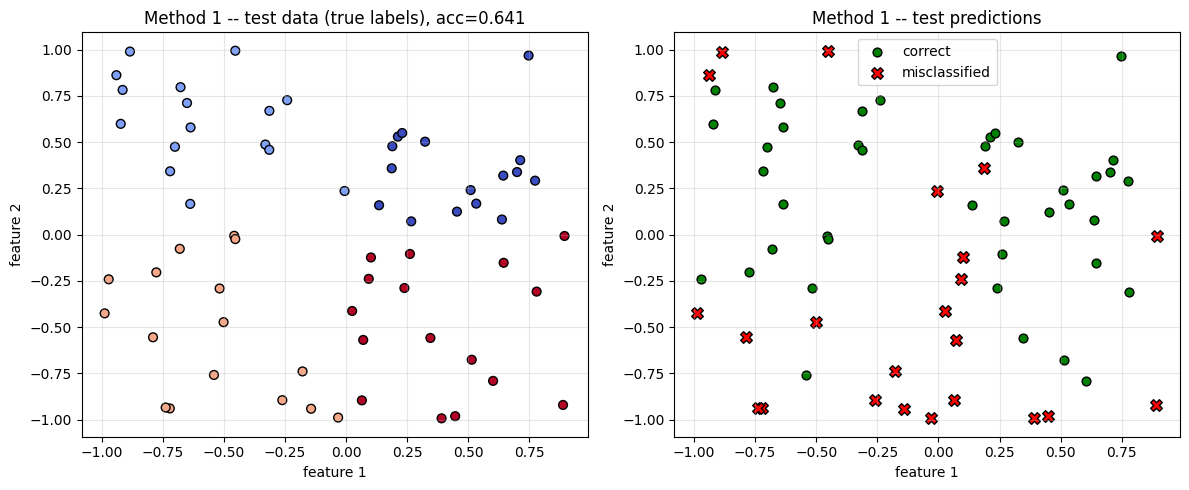

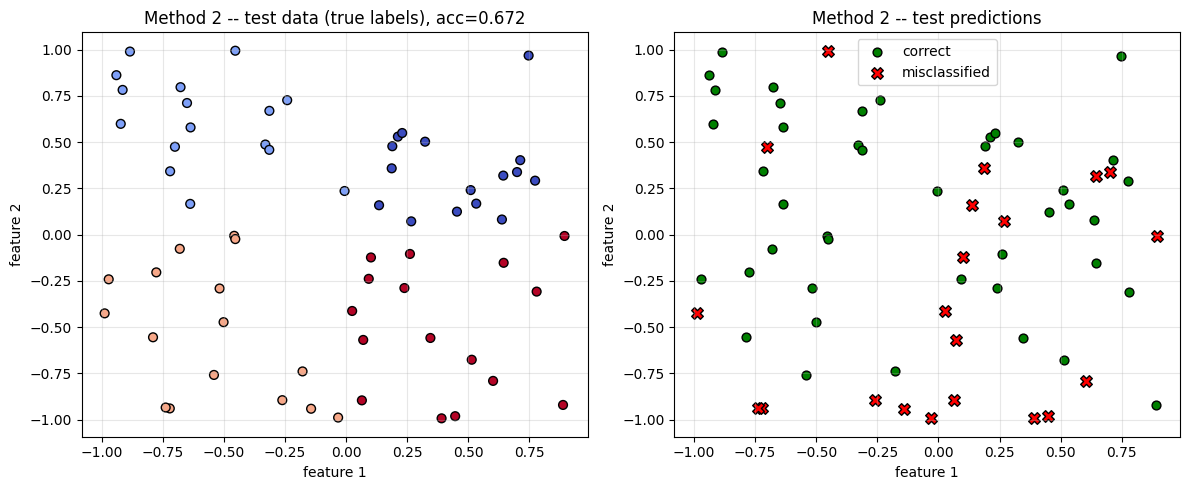

In [11]:
if PLOT_DECISION_BOUNDARY:
    allX = np.vstack([train_data, test_data])
    pad = 0.2
    x_min, x_max = allX[:, 0].min() - pad, allX[:, 0].max() + pad
    y_min, y_max = allX[:, 1].min() - pad, allX[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, GRID_RES),
                         np.linspace(y_min, y_max, GRID_RES))
    grid = np.c_[xx.ravel(), yy.ravel()]

for METHOD in METHODS:
    final_params = results[METHOD]["final_params"]
    final_train_acc, train_pred = performance_evaluation(train_data, train_labels, final_params)
    final_test_acc,  test_pred  = performance_evaluation(test_data,  test_labels,  final_params)
    test_pred = np.array(test_pred)
    results[METHOD]["final_train_acc"] = final_train_acc
    results[METHOD]["final_test_acc"]  = final_test_acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if PLOT_DECISION_BOUNDARY:
        print(f"Method {METHOD}: evaluating {GRID_RES}x{GRID_RES} decision-boundary grid...")
        probs = clf1.classification_probability(grid, final_params)
        zz = np.argmax(probs, axis=1).reshape(xx.shape)
        for ax in axes:
            ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
                       cmap=CLASS_COLORS, norm=CLASS_NORM, alpha=0.45)

    ax = axes[0]
    ax.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, cmap=CLASS_COLORS,
               norm=CLASS_NORM, edgecolors="k", s=40)
    ax.set_title(f"Method {METHOD} -- test data (true labels), acc={final_test_acc:.3f}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2"); ax.grid(alpha=0.3)

    ax = axes[1]
    correct = test_pred == test_labels
    ax.scatter(test_data[correct, 0], test_data[correct, 1], c="green",
               edgecolors="k", s=40, label="correct")
    ax.scatter(test_data[~correct, 0], test_data[~correct, 1], c="red",
               marker="X", edgecolors="k", s=70, label="misclassified")
    ax.set_title(f"Method {METHOD} -- test predictions")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

## 10. Final performance summary

In [12]:
print(f"Dataset: checkerboard-4L-4Q / dataset{DATASET_NUM}    Mode: {MODE}    Framework: PennyLane\n")

rows = []
for METHOD in METHODS:
    h = results[METHOD]["history"]
    rows.append({
        "method": METHOD,
        "final_train_acc": round(results[METHOD]["final_train_acc"], 4),
        "final_test_acc":  round(results[METHOD]["final_test_acc"], 4),
        "best_test_acc":   round(max(h["test_accuracies"]), 4),
        "best_train_acc":  round(max(h["train_accuracies"]), 4),
        "final_cost":      round(h["final_cost"], 6),
    })

summary_methods = pd.DataFrame(rows).set_index("method")
display(summary_methods)

Dataset: checkerboard-4L-4Q / dataset1    Mode: load    Framework: PennyLane



,final_train_acc,final_test_acc,best_test_acc,best_train_acc,final_cost
method,,,,,
1,0.7188,0.6406,0.7500,0.7812,0.707387
2,0.7109,0.6719,0.6875,0.7344,0.661091


## 11. (Optional) Compare all 10 instances

A quick aggregate view across `dataset1` ... `dataset10` for the chosen
`METHOD`, read from the Qiskit-saved results (the training-history numbers are
framework-agnostic). This does not depend on the single-dataset selection
above.


===== checkerboard-4L-4Q -- Method 1 (all 10 instances, Qiskit-trained params) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.6406,0.7500,0.7188,0.7074
2,0.6875,0.7656,0.6641,0.7877
3,0.4688,0.5000,0.5391,1.0882
4,0.4531,0.5469,0.6250,1.0376
5,0.7031,0.7812,0.7734,0.7633
6,0.7188,0.7969,0.7812,0.7197
7,0.3594,0.4219,0.4688,1.2020
8,0.7344,0.7500,0.7188,0.7444
9,0.4062,0.4844,0.6016,1.0314


Mean final test accuracy: 0.5687 +/- 0.1429


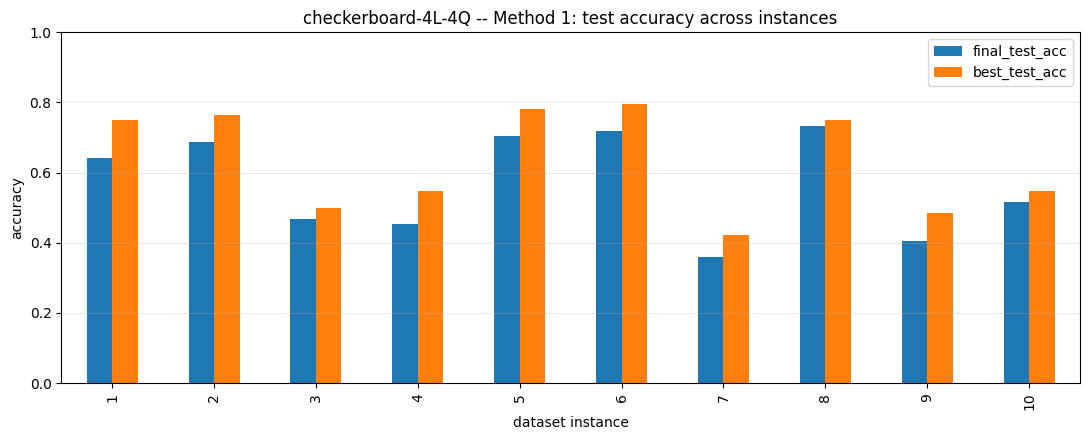


===== checkerboard-4L-4Q -- Method 2 (all 10 instances, Qiskit-trained params) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.6719,0.6875,0.7109,0.6611
2,0.4844,0.5000,0.4922,0.8714
3,0.7656,0.8438,0.7188,0.6841
4,0.6719,0.7500,0.6719,0.6079
5,0.5156,0.5781,0.5469,0.7699
6,0.5938,0.6250,0.6250,0.7805
7,0.5469,0.6094,0.5547,0.8357
8,0.5625,0.6562,0.4609,0.9412
9,0.4844,0.5000,0.5859,0.8033


Mean final test accuracy: 0.5828 +/- 0.0929


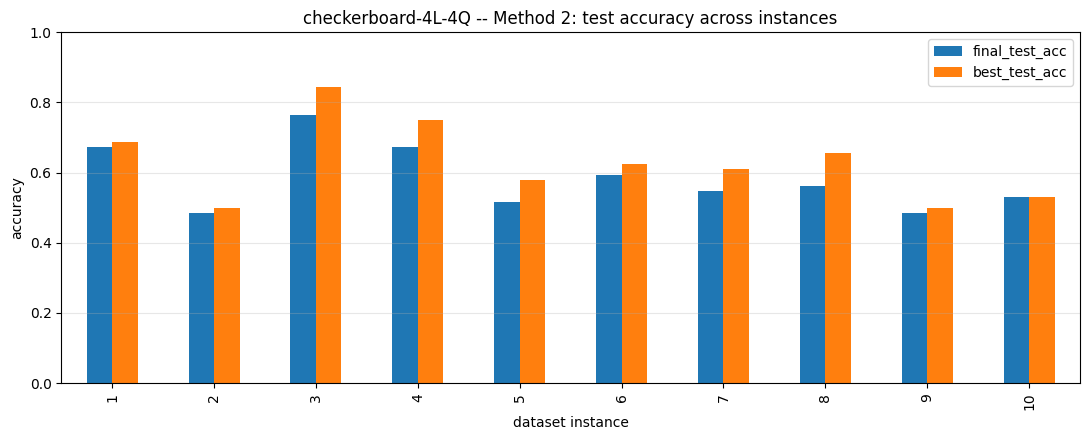

In [13]:
for METHOD in METHODS:
    rows = []
    for n in range(1, 11):
        pattern = os.path.abspath(os.path.join("..", "results", f"checkerboard-4L-4Q-dataset{n}",
                                                f"results_spsa_method{METHOD}_*.json"))
        matches = sorted(glob.glob(pattern))
        if not matches:
            continue
        with open(matches[-1], encoding="utf-8") as f:
            s = json.load(f)
        fr, th = s["final_results"], s["training_history"]
        rows.append({
            "dataset": n,
            "final_test_acc": fr["final_test_accuracy"],
            "best_test_acc":  max(th["test_accuracies"]),
            "final_train_acc": fr["final_train_accuracy"],
            "final_cost": fr["final_cost"],
        })

    summary = pd.DataFrame(rows).set_index("dataset")
    print(f"\n===== checkerboard-4L-4Q -- Method {METHOD} (all 10 instances, Qiskit-trained params) =====")
    display(summary.round(4))
    print(f"Mean final test accuracy: "
          f"{summary['final_test_acc'].mean():.4f} +/- {summary['final_test_acc'].std():.4f}")

    ax = summary[["final_test_acc", "best_test_acc"]].plot.bar(figsize=(11, 4.5))
    ax.set_title(f"checkerboard-4L-4Q -- Method {METHOD}: test accuracy across instances")
    ax.set_xlabel("dataset instance"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()